# Proyecto: Predicción inteligente de gasto en clientes e-commerce


**Descripción del objetivo del negocio**            

La empresa de e-commerce busca optimizar su estrategia de marketing mediante la personalización de ofertas para sus clientes. Para lograrlo, necesita comprender y anticipar el comportamiento de compra de los usuarios a partir de sus interacciones con la plataforma digital.               

En particular, el objetivo del negocio es predecir el gasto anual de los clientes, utilizando información relacionada con su comportamiento en la plataforma, como la duración promedio de sus sesiones, el tiempo que pasan en la aplicación móvil o en el sitio web, y la antigüedad que tienen como miembros del servicio.               

Contar con un modelo predictivo de este tipo permitiría a la empresa:               

identificar clientes con mayor potencial de gasto,          

diseñar campañas de marketing más personalizadas,       

optimizar la asignación de recursos comerciales,        

mejorar la experiencia del cliente mediante recomendaciones más relevantes.         

En este contexto, el uso de técnicas de aprendizaje automático supervisado permite construir un modelo capaz de aprender patrones a partir de datos históricos y generar estimaciones del gasto esperado de los clientes.           

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("Ecommerce Customers.csv")

df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


Reviso estructura del Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


Con el objetivo de incorporar una variable categórica útil para el modelo, se extrajo el estado de residencia del cliente a partir de la columna Address. Esta información fue utilizada para crear una nueva variable llamada State, que representa el estado de Estados Unidos donde reside el cliente. Posteriormente, las columnas Email, Address y Avatar fueron eliminadas debido a que no aportan valor predictivo al modelo. Finalmente, la variable categórica State fue transformada a variables numéricas mediante la técnica de One-Hot Encoding, lo que permite que el modelo de aprendizaje automático pueda utilizar esta información durante el entrenamiento.

In [6]:
df["State"] = df["Address"].str.extract(r',\s([A-Z]{2})\s')

In [7]:
df[["Address", "State"]].head()

,Address,State
0,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",MI
1,"4547 Archer Common\nDiazchester, CA 06566-8576",CA
2,"24645 Valerie Unions Suite 582\nCobbborough, D...",DC
3,"1414 David Throughway\nPort Jason, OH 22070-1220",OH
4,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",PR


In [8]:
#Verifico Estados únicos y su frecuencia
df["State"].value_counts()

State
MO    13
SC    13
DE    13
OR    12
VT    12
MS    11
FL    11
KS    11
MN    11
NC    10
NJ    10
HI     9
AL     9
WV     9
ME     9
ND     9
MI     9
AS     9
AZ     9
KY     8
GA     8
FM     8
IL     8
PA     8
NY     8
TX     8
MT     8
MA     7
IA     7
OK     7
RI     7
NH     7
AK     7
IN     7
MH     7
SD     7
DC     7
WY     7
PR     7
NM     6
CA     6
PW     6
VI     6
AR     6
VA     6
GU     6
NE     6
LA     6
NV     6
OH     5
MP     5
CT     5
CO     5
TN     5
UT     5
MD     5
WI     5
WA     4
ID     3
Name: count, dtype: int64

In [9]:
df["State"].nunique()

59

Elimino variables innecesarias para el proyecto

In [10]:
df = df.drop(["Email", "Address", "Avatar"], axis=1)

Reviso valores nulos

In [11]:
df.isnull().sum()

Avg. Session Length      0
Time on App              0
Time on Website          0
Length of Membership     0
Yearly Amount Spent      0
State                   46
dtype: int64

Reviso el Dataset

In [12]:
df.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,State
0,34.497268,12.655651,39.577668,4.082621,587.951054,MI
1,31.926272,11.109461,37.268959,2.664034,392.204933,CA
2,33.000915,11.330278,37.110597,4.104543,487.547505,DC
3,34.305557,13.717514,36.721283,3.120179,581.852344,OH
4,33.330673,12.795189,37.536653,4.446308,599.406092,PR


**Tabla de variables y su descripción**

| Variable (Inglés)    | Variable (Español)            | Tipo de variable      | Unidad de medida |
| -------------------- | ----------------------------- | --------------------- | ---------------- |
| Avg. Session Length  | Duración promedio de sesión   | Cuantitativa continua | Minutos          |
| Time on App          | Tiempo en la aplicación móvil | Cuantitativa continua | Minutos          |
| Time on Website      | Tiempo en el sitio web        | Cuantitativa continua | Minutos          |
| Length of Membership | Antigüedad del cliente        | Cuantitativa continua | Años             |
| Yearly Amount Spent  | Gasto anual del cliente       | Cuantitativa continua | Dólares (USD)    |


Guardo el dataset limpio y lo vuelvo a cargar para trabajar con este nuevo dataset

In [13]:
df.to_csv("ecommerce_ml_dataset.csv", index=False)
df = pd.read_csv("ecommerce_ml_dataset.csv")

<b><font color= "red">Lección 1: Fundamentos del Aprendizaje de Máquina</b></font>                 
<b>Comprender los fundamentos del aprendizaje supervisado. </b>


**Diferenciar problemas de clasiﬁcación y regresión**

En el aprendizaje supervisado existen distintos tipos de problemas dependiendo de la naturaleza de la variable que se desea predecir. Dos de los más comunes son clasificación y regresión.

<u>Problemas de clasificación</u>

Los problemas de clasificación buscan asignar una observación a una categoría o clase específica. En este caso, la variable objetivo es categórica y toma valores discretos que representan diferentes grupos. En estos casos, el modelo aprende a separar observaciones en categorías previamente definidas.

Ejemplos de clasificación:              

| Problema                                    | Variable objetivo   |
| ------------------------------------------- | ------------------- |
| Detectar si un correo es spam               | Spam / No spam      |
| Clasificar clientes según riesgo crediticio | Alto / Medio / Bajo |
| Predecir si un cliente realizará una compra | Sí / No             |


<u>Problemas de regresión</u>

Los problemas de regresión, en cambio, buscan predecir un valor numérico continuo. La variable objetivo puede tomar una amplia gama de valores dentro de un intervalo. En estos casos, el modelo aprende la relación entre las variables predictoras y la variable objetivo para estimar un valor numérico.

Ejemplos de regresión:          

| Problema                           | Variable objetivo |
| ---------------------------------- | ----------------- |
| Predecir el precio de una vivienda | Valor monetario   |
| Estimar la temperatura futura      | Grados            |
| Predecir el gasto de un cliente    | Monto de dinero   |




**Identiﬁcar las etapas del pipeline de un proyecto Machine Learning**

Un proyecto de "Aprendizaje Autompatico" generalmente sigue una serie de etapas estructuradas conocidas como pipeline de Machine Learning, que permiten organizar el desarrollo del modelo de manera sistemática.

Las principales etapas son:

**1.-Definición o comprensión del problema**

En esta etapa se define el objetivo del negocio y se determina qué tipo de problema de aprendizaje automático se debe abordar (clasificación, regresión, etc.).

**2.-Recolección y preparación de los datos**

Aquí se identiﬁcan las fuentes de datos relevantes y se procede a la recopilación de información. Una vez obtenidos los datos, se realiza la limpieza, eliminación de duplicados, tratamiento de valores nulos y normalización, garantizando que los datos sean aptos para el entrenamiento de los modelos. En este punto se realiza el preprocesamiento de los datos que consiste en preparar los datos para el entrenamiento del modelo. Algunas tareas comunes incluyen:

limpieza de datos

tratamiento de valores faltantes

codificación de variables categóricas

normalización o estandarización de variables

**3.-Análisis exploratorio de los datos (EDA - Exploratory Data Analysis)**

En este paso, se analiza la distribución de los datos, se identiﬁcan relaciones, patrones y posibles outliers. Esta etapa es crucial para comprender las características de los datos y guiar la selección de las técnicas y modelos a utilizar.

**4.-Selección del modelo y técnica de aprendizaje**

Dependiendo del problema, se elige un algoritmo supervisado o no supervisado. También se decide el tipo de tarea
(clasiﬁcación, regresión, clustering) y la métrica de evaluación más adecuada para medir el desempeño del modelo.

**5.-División del conjunto de datos**

Los datos se separan en conjuntos de entrenamiento, validación y prueba. Esta división permite evaluar el comportamiento del modelo y evitar problemas de sobreajuste, asegurando que el modelo generalice correctamente nuevos datos.
El dataset se divide generalmente en:

conjunto de entrenamiento, utilizado para entrenar el modelo

conjunto de prueba, utilizado para evaluar su rendimiento

**6.-Entrenamiento y ajuste del modelo**

En este punto, el modelo aprende a partir de los datos de entrenamiento. Se aplican algoritmos de aprendizaje automático para aprender la relación entre las variables predictoras y la variable objetivo. Además, se realizan ajustes de hiperparámetros y se prueba con los datos de validación para mejorar la precisión y evitar errores.

**7.-Evaluación del modelo**

Se utilizan métricas específicas para evaluar el desempeño del modelo y determinar qué tan bien realiza sus predicciones.

En problemas de regresión suelen utilizarse métricas como:

- Precisión
- Recall
- F1-score
- MAE (Mean Absolute Error)       
- RMSE (Root Mean Squared Error)      
- R² (coeficiente de determinación)      

**8.-Implementación y monitoreo en producción**

El modelo se integra en un entorno real para  uso continuo, y es fundamental establecer un monitoreo constante para
identiﬁcar posibles degradaciones de rendimiento y actualizarlo según sea necesario.


<u>Estas etapas forman un ciclo continuo de mejora y ajuste, ya que los modelos deben adaptarse a los cambios en los datos y necesidades del negocio.</u>



**Deﬁnir el problema como regresión supervisada.**

El problema abordado en este proyecto corresponde a un problema de aprendizaje supervisado de tipo regresión.

Se considera aprendizaje supervisado porque el conjunto de datos contiene una variable objetivo conocida, denominada Yearly Amount Spent, que representa el gasto anual de cada cliente en la plataforma de e-commerce.

El modelo utilizará otras variables del dataset, tales como:

duración promedio de sesión

tiempo en la aplicación móvil

tiempo en el sitio web

antigüedad del cliente

para aprender la relación existente entre estas características y el gasto anual de los clientes.

Dado que la variable objetivo corresponde a un valor numérico continuo, el objetivo del modelo será estimar el monto de gasto anual esperado para cada cliente, lo cual corresponde a un problema de regresión.

De forma simplificada, el modelo busca aprender una función de la forma:

                            f(x)-->y

donde:

x representa las variables predictoras relacionadas con el comportamiento del cliente,

y corresponde al gasto anual del cliente.

De esta manera, el modelo podrá generar estimaciones del gasto esperado de nuevos clientes a partir de sus características y comportamiento dentro de la plataforma.

Una vez limpio el dataset y definidos los primeros lineamientos del proyecto, se procede a definir las variables del modelo. Las variables predictoras se agrupan en la matriz x, mientras que la variable objetivo corresponde al gasto anual del cliente (Yearly Amount Spent), que se almacena en el vector y.

Aunque se creó la variable categórica State, esta no fue utilizada en el entrenamiento del modelo en esta etapa del proyecto, ya que aún no se ha realizado el proceso de codificación necesario para convertir variables categóricas en formato numérico. Por lo tanto, el modelo de regresión lineal fue entrenado únicamente con las variables numéricas disponibles. La variable State será incorporada posteriormente durante la etapa de preprocesamiento de datos.

In [14]:
x = df.drop(["Yearly Amount Spent", "State"], axis=1)
y = df["Yearly Amount Spent"]

Verifico dimensiones

In [15]:
print("Dimensiones de x:", x.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de x: (500, 4)
Dimensiones de y: (500,)


<b><font color= "red">Lección 2: Nivel de ajuste del modelo y validación cruzada</b></font>                 
<b>Evaluar si el modelo está bien ajustado usando validación cruzada. </b>

**Calcular y analizar los errores de entrenamiento y prueba.**

Separar datos de entrenamiento y prueba

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Datos entrenamiento:", x_train.shape)
print("Datos prueba:", x_test.shape)

Datos entrenamiento: (400, 4)
Datos prueba: (100, 4)


Entreno el modelo de regresión

In [17]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Predicciones del modelo

In [18]:
y_train_pred = modelo.predict(x_train)
y_test_pred = modelo.predict(x_test)

Calculo errores de entrenamiento y prueba

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("----- Entrenamiento -----")
print("MAE:", f"{mean_absolute_error(y_train, y_train_pred):.4f}")
print("RMSE:", f"{np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print("R2:", f"{r2_score(y_train, y_train_pred):.4f}")

print("\n----- Prueba -----")
print("MAE:", f"{mean_absolute_error(y_test, y_test_pred):.4f}")
print("RMSE:", f"{np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print("R2:", f"{r2_score(y_test, y_test_pred):.4f}")

----- Entrenamiento -----
MAE: 7.7270
RMSE: 9.7889
R2: 0.9854

----- Prueba -----
MAE: 8.5584
RMSE: 10.4816
R2: 0.9778


<u>MAE (Error absoluto medio)</u>          

- Entrenamiento: 7.73           
- Prueba: 8.56              

Esto significa que, en promedio, el modelo se equivoca aproximadamente entre 7 y 9 dólares al predecir el gasto anual de un cliente. Si consideramos que el gasto anual en promedio por cliete es de 500 USD, este sería menos del 2%.

Además, la diferencia entre entrenamiento y prueba es pequeña, lo que es una buena señal. lo que indica que, el modelo aprendió patrones reales del problema, no depende solo de los datos específicos de entrenamiento y puede hacer buenas predicciones en datos nuevos, por lo que tiene buena capacidad de generalización.


<u>RMSE (Raíz del error cuadrático medio)</u>

- Entrenamiento: 9.79       
- Prueba: 10.48            

El RMSE penaliza más los errores grandes, el hecho de que el RMSE sea similar en ambos conjuntos indica que no hay errores extremos importantes en el conjunto de prueba.


<u>Interpretación del R²</u>            

El R² (coeficiente de determinación) indica qué proporción de la variabilidad del gasto anual es explicada por el modelo.       

- Entrenamiento: 0.9854     
- Prueba: 0.9778            

Esto significa que el modelo explica aproximadamente:
- 98.5% de la variabilidad en entrenamiento         
- 97.8% en datos nuevos             

Esto es muy alto y muestra que el modelo tiene un excelente ajuste.


La diferencia entre las métricas de entrenamiento y prueba es pequeña, lo que indica que el modelo mantiene un rendimiento similar al aplicarse a datos que no fueron utilizados durante el entrenamiento. Esto sugiere que el modelo ha aprendido patrones generales presentes en los datos y no ha memorizado únicamente el conjunto de entrenamiento. Por lo tanto, el modelo presenta una buena capacidad de generalización y no muestra señales evidentes de sobreajuste.

**Identiﬁcar sobreajuste y subajuste**

<u>Evaluación de sobreajuste (overfitting)</u>          

El sobreajuste ocurre cuando el modelo funciona mucho mejor en entrenamiento que en prueba.
En este caso:

Dataset	R²
- Entrenamiento:	0.9854
- Prueba:	0.9778              

La diferencia es muy pequeña (~0.0076). Por lo tanto **no hay evidencia de sobreajuste**


<u>Evaluación de subajuste (underfitting)</u>           

El subajuste ocurre cuando el modelo no logra capturar la relación entre variables, por lo que el rendimiento es bajo tanto en entrenamiento como en prueba.

En este caso, ambos R² son muy altos, por lo que, el modelo explica más del 97% de la variabilidad del gasto y sí está capturando el patrón de los datos. Además, los errores son bajos.

Por lo tanto, **no hay evidencia de subajuste.**


Al comparar las métricas obtenidas en los conjuntos de entrenamiento y prueba se observa que los valores de MAE, RMSE y R² son muy similares entre ambos conjuntos. Esto indica que el modelo mantiene un rendimiento consistente al aplicarse a datos no utilizados durante el entrenamiento.
La pequeña diferencia entre los valores de R² (0.9854 en entrenamiento y 0.9778 en prueba) sugiere que el modelo no presenta problemas de sobreajuste. Además, el alto valor de R² en ambos conjuntos indica que el modelo captura adecuadamente la relación entre las variables predictoras y el gasto anual del cliente, por lo que tampoco se observan señales de subajuste.
En consecuencia, el modelo de regresión lineal presenta un buen nivel de ajuste y una adecuada capacidad de generalización.

**Implementar validación cruzada con K-Folds**

In [20]:
from sklearn.model_selection import cross_val_score

modelo = LinearRegression()
scores = cross_val_score(modelo,x,y,cv=5,scoring="r2")

print("R2 en cada fold:", f"{scores}")
print("R2 promedio:", f"{scores.mean():.4f}")
print("Desviación estándar de R2 (Variabilidad):", f"{scores.std():.4f}")

R2 en cada fold: [0.98274654 0.9821047  0.98717189 0.9842572  0.98219012]
R2 promedio: 0.9837
Desviación estándar de R2 (Variabilidad): 0.0019


En K-Fold Cross Validation, el modelo se entrena K veces, cada vez usa K-1 folds para entrenamiento y 1 fold para validación, calculando el R² en cada iteración.

El R² promedio = 0.9837 indica que, el modelo explica aproximadamente 98.37% de la variabilidad del gasto anual cuando se entrena y evalúa en distintos subconjuntos del dataset. Esto es una señal de muy buen rendimiento del modelo.         

Además, es consistente con lo que se obtuvo antes:                  

-	**El R² de cross-validation (0.9837) es muy parecido al R² de test (0.9778).**          

Eso refuerza aún más que tu modelo no está sobreajustado e indica que los resultados son robustos.

<u>Al interpretar los valores en cada fold,</u> se observa que todos los valores están en un rango muy pequeño. Esto significa que:     

-	el modelo funciona bien sin importar qué parte del dataset se utilice para entrenar             
-	el rendimiento es consistente entre distintas particiones de datos              

Eso indica estabilidad del modelo.

En cuanto a la <u>desviación estándar,</u> ésta mide cuánto varía el rendimiento entre folds.           

En este caso= 0.0019, menor a 0.01, lo cual es extremadamente bajo. Indicando que el rendimiento del modelo casi no cambia entre folds.             

Los resultados de la validación cruzada mediante K-Fold muestran valores de R² consistentes en cada una de las particiones del dataset, con resultados que varían entre 0.9821 y 0.9872. El R² promedio obtenido es de 0.9837, lo que indica que el modelo logra explicar aproximadamente el 98.37% de la variabilidad del gasto anual de los clientes.
Además, la desviación estándar de los valores de R² es de 0.0019, lo que evidencia una variabilidad muy baja entre los distintos folds. Esto sugiere que el modelo presenta un comportamiento estable y robusto frente a diferentes particiones de los datos. En conjunto, estos resultados indican que el modelo posee una buena capacidad de generalización y un ajuste adecuado.


<b><font color= "red">Lección 3: Preprocesamiento y escalamiento de datos</b></font>                 
<b>Preparar correctamente los datos para el entrenamiento del modelo. </b>

**Tratar valores nulos y outliers**

In [21]:
df.isnull().sum()

Avg. Session Length      0
Time on App              0
Time on Website          0
Length of Membership     0
Yearly Amount Spent      0
State                   46
dtype: int64

Realizo lista con las iniciales de los Estados de USA, para clasificarlos

Durante la extracción del estado desde la variable Address, se identificaron múltiples valores únicos que no corresponden a estados oficiales de Estados Unidos. Esto se debe a que las direcciones del dataset fueron generadas artificialmente y presentan formatos inconsistentes. Para solucionar este problema, se filtraron únicamente las abreviaciones oficiales de los 50 estados de EE. UU., mientras que los valores no válidos fueron agrupados en una categoría denominada "Unknown".

In [22]:
us_states = [
"AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
"HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
"MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
"NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
"SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
]

Códifico tanto valores que no corresponden a un estado, como valores nulos a categoría "Unknown" o desconocido

In [23]:
df["State"] = df["State"].apply(lambda x: x if x in us_states else "Unknown")

In [24]:
df["State"].nunique()

51

In [25]:
df.isnull().sum()

Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
State                   0
dtype: int64

**Detección de outliers**

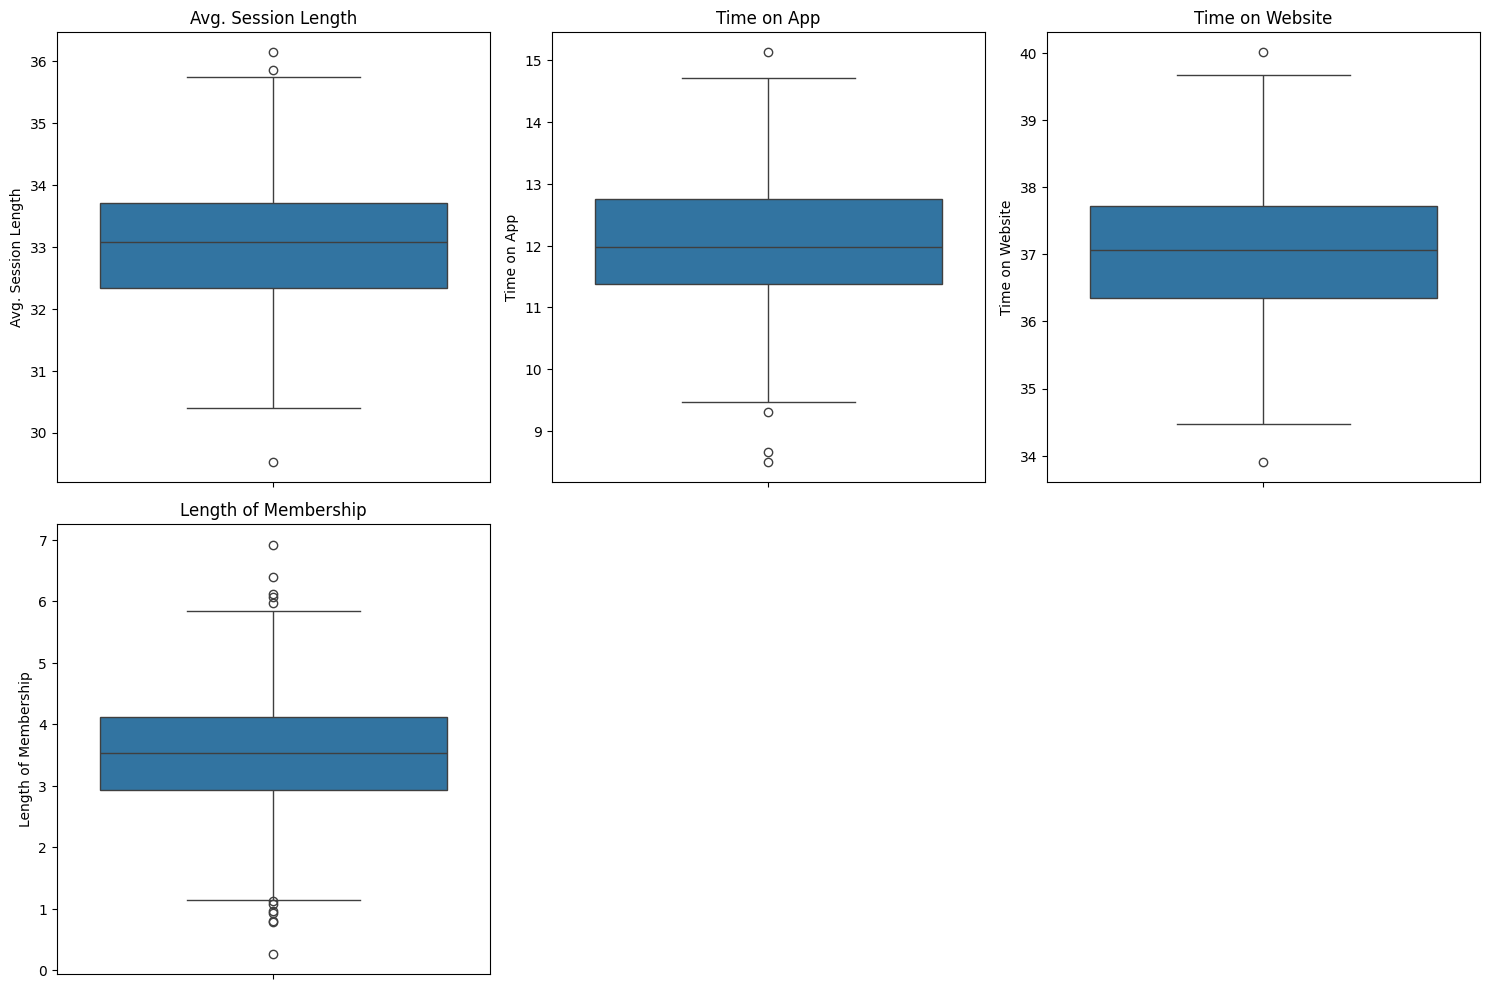

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# variables predictoras (excluyendo la variable objetivo)
features = df.drop(["Yearly Amount Spent", "State"], axis=1)

# número de columnas de la grilla
cols = 3
rows = (len(features.columns) + cols - 1) // cols

plt.figure(figsize=(15, 10))

for i, col in enumerate(features.columns, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

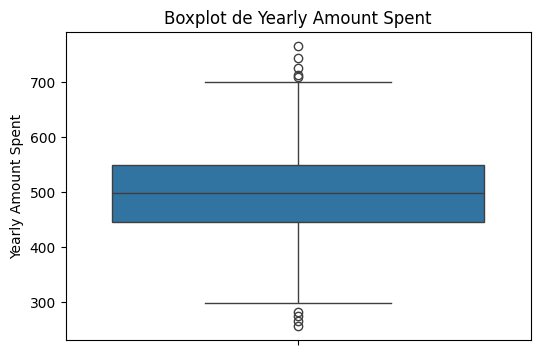

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Yearly Amount Spent"])
plt.title("Boxplot de Yearly Amount Spent")
plt.show()

In [28]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [29]:
import pandas as pd

# variables numéricas
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

outliers_summary = {}

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outliers_summary[col] = len(outliers)

outliers_summary

{'Avg. Session Length': 3,
 'Time on App': 4,
 'Time on Website': 2,
 'Length of Membership': 12,
 'Yearly Amount Spent': 9}

In [30]:
outliers_df = pd.DataFrame(list(outliers_summary.items()),
                           columns=["Variable","Cantidad_Outliers"])

outliers_df

,Variable,Cantidad_Outliers
0,Avg. Session Length,3
1,Time on App,4
2,Time on Website,2
3,Length of Membership,12
4,Yearly Amount Spent,9


Para identificar valores atípicos se utilizó el método del rango intercuartílico (IQR). Este método considera como outliers aquellos valores que se encuentran por debajo de Q1 - 1.5× IQR o o por encima de Q3 + 1.5× IQR.
El análisis mostró que algunas variables presentan un número reducido de valores atípicos. Sin embargo, estos valores no fueron eliminados debido a que en datasets de comportamiento de clientes pueden representar variaciones reales dentro de la población analizada y no necesariamente errores en los datos. Por lo tanto, se decidió mantenerlos para no perder información relevante durante el entrenamiento del modelo.

Además, en este Dataset específico (Ecommerce Customers)  hay muy pocos outliers, lo cual explica porqué el modelo logró R² ≈ 0.98.

**Aplicar codiﬁcación a variables categóricas.**

Debido a que los algoritmos de aprendizaje automático solo pueden trabajar con datos numéricos, para incorporar la variable categórica State en el modelo se aplicó un proceso de codificación basado en One-Hot Encoding. Posteriormente se eliminó una de las categorías utilizando la opción drop_first=True, generando así variables dummy. Esta decisión se tomó para evitar el problema de multicolinealidad conocido como dummy variable trap, que puede afectar a modelos de regresión lineal cuando existe dependencia perfecta entre las variables explicativas.

In [31]:
df_model=df.copy()
df_model = pd.get_dummies(df, columns=["State"], drop_first=True)

In [32]:
df_model

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,State_AL,State_AR,State_AZ,State_CA,State_CO,...,State_TN,State_TX,State_UT,State_Unknown,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,34.497268,12.655651,39.577668,4.082621,587.951054,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,31.926272,11.109461,37.268959,2.664034,392.204933,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,33.000915,11.330278,37.110597,4.104543,487.547505,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,34.305557,13.717514,36.721283,3.120179,581.852344,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,33.330673,12.795189,37.536653,4.446308,599.406092,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573,573.847438,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
496,34.702529,11.695736,37.190268,3.576526,529.049004,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
497,32.646777,11.499409,38.332576,4.958264,551.620145,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
498,33.322501,12.391423,36.840086,2.336485,456.469510,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


Para incorporar la variable categórica State en el modelo se aplicó One-Hot Encoding, técnica que transforma cada categoría en una variable binaria independiente. Esta elección se realizó debido a que los estados no presentan una relación ordinal entre sí, por lo que métodos como Label Encoding podrían inducir una interpretación errónea de jerarquía por parte del modelo. Al utilizar One-Hot Encoding se evita introducir relaciones artificiales entre las categorías, permitiendo que el modelo de regresión lineal trate cada estado como una categoría independiente.

**Normalizar y/o estandarizar los datos.**

Con el objetivo de asegurar que todas las variables contribuyan de manera equilibrada al modelo, se aplicó un proceso de estandarización utilizando StandardScaler. Este método transforma las variables para que tengan media cero y desviación estándar uno, permitiendo que todas las variables se encuentren en una escala comparable.

En el preprocesamiento de los datos se aplicó estandarización utilizando StandardScaler. Para evitar el problema de data leakage, el escalador se ajustó únicamente utilizando los datos de entrenamiento (fit_transform), mientras que los datos de prueba se transformaron posteriormente usando los mismos parámetros (transform). Esto garantiza que la información del conjunto de prueba no influya en el proceso de entrenamiento del modelo.

Las variables numéricas fueron estandarizadas utilizando StandardScaler con el fin de garantizar que todas las variables continuas se encuentren en una escala comparable. Por otro lado, la variable categórica State fue transformada mediante One-Hot Encoding, generando variables dummy binarias. Estas variables no fueron escaladas debido a que ya se encuentran en un rango entre 0 y 1 y representan categorías discretas.

**PRUEBA PIPELINE**

In [33]:
#Separo nuevamente variables predictoras y objetivo
x = df_model.drop("Yearly Amount Spent", axis=1)
y = df_model["Yearly Amount Spent"]

In [34]:
#Defino variables numéricas y categóricas
numeric_cols = [
    "Avg. Session Length",
    "Time on App",
    "Time on Website",
    "Length of Membership"
]

cat_cols = [col for col in x.columns if col.startswith("State_")]

In [35]:
#Divido en entrenamiento y prueba
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", "passthrough", cat_cols)
    ]
)

In [40]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

In [41]:
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [42]:
X_train_pipeline = pipeline.named_steps["preprocessing"].transform(x_train)

In [43]:
X_train_pipeline

array([[ 0.72875642, -0.14037637, -0.17321599, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.23367035, -0.23549152, -0.70076461, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44946538,  1.93596147,  0.16698241, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.26587083, -1.17327098, -2.08875055, ...,  0.        ,
         0.        ,  0.        ],
       [-0.81225043,  2.07956541,  0.00264921, ...,  0.        ,
         0.        ,  0.        ],
       [-0.64425634, -0.61010223,  0.55038981, ...,  0.        ,
         0.        ,  0.        ]], shape=(400, 54))

In [ ]:
y_pred = pipeline.predict(x_test)